Sims

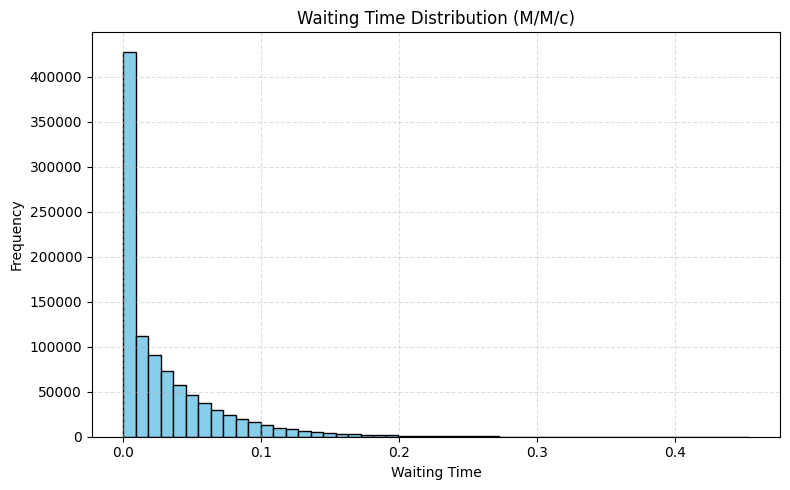

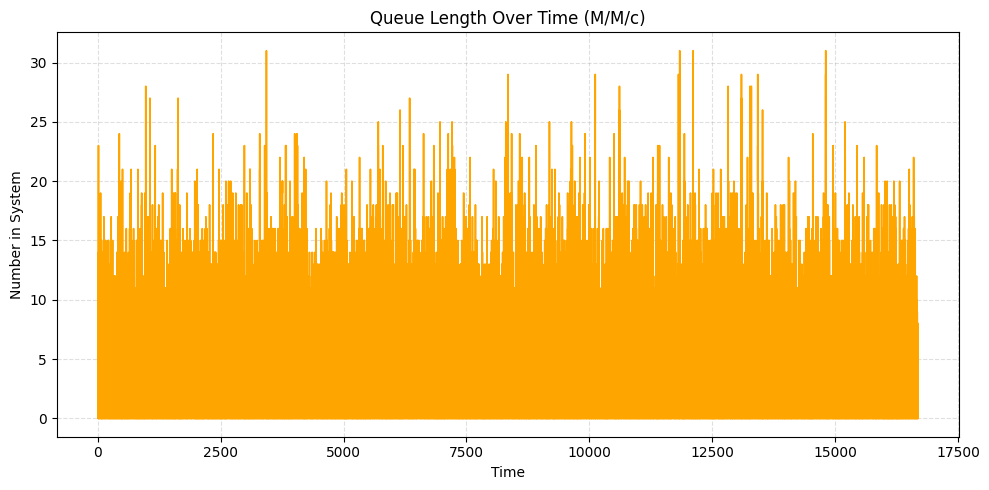


=== Simulation vs. Theory (M/M/c) ===
Parameters: lambda=60, mu=84, c=1, n=1000000
Per-server Utilization (rho): 0.7143
Probability of Waiting (Erlang C): 0.714286

Avg System Time (W):   sim=0.041602  |  theory=0.041667
Avg Waiting Time (Wq): sim=0.029715          |  theory=0.029762
Avg # in System (L):   sim=2.493323         |  theory=2.500000
Avg # in Queue (Lq):   sim=1.780939        |  theory=1.785714


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ----------- Helpers -----------
def exp_rv(rate, n):
    """Generate exponential RVs with given rate."""
    return np.random.exponential(1 / rate, n)

def generate_arrivals(lambda_, n):
    """Arrival epochs via cumulative sum of exponential inter-arrival times."""
    inter = exp_rv(lambda_, n)
    return np.cumsum(inter)

# ----------- Theory for M/M/c (Erlang C) -----------
def theory_mmc(lambda_, mu, c):
    """
    Theoretical metrics for M/M/c (no blocking, FIFO, exponential service):
    Returns dict with rho, P_wait (Erlang C), Wq, W, Lq, L, and per-server utilization.
    """
    a = lambda_ / mu            # offered load
    rho = a / c                 # per-server utilization

    if rho >= 1:
        # Unstable (no finite steady state)
        return {
            "rho": rho,
            "utilization_per_server": rho,
            "P_wait": 1.0,
            "Wq": np.inf,
            "W": np.inf,
            "Lq": np.inf,
            "L": np.inf,
        }

    # Compute P0 using recursion (avoid factorials)
    sum_terms = 0.0
    term = 1.0  # a^0 / 0! = 1
    for n in range(c):
        sum_terms += term
        term *= a / (n + 1)  # now term = a^{n+1}/(n+1)!
    # Now term = a^c / c!
    P0 = 1.0 / (sum_terms + term * (1.0 / (1.0 - rho)))

    # Erlang C (probability an arrival has to wait)
    P_wait = term * (1.0 / (1.0 - rho)) * P0

    # Average number in queue (Lq), waiting time (Wq), system time (W), number in system (L)
    Lq = P_wait * (rho / (1.0 - rho))
    Wq = Lq / lambda_
    W = Wq + 1.0 / mu
    L = lambda_ * W

    return {
        "rho": rho,
        "utilization_per_server": rho,
        "P_wait": P_wait,
        "Wq": Wq,
        "W": W,
        "Lq": Lq,
        "L": L,
    }

# ----------- M/M/c Simulation -----------
def simulate_mmc(lambda_, mu, c, n, show_plots=True):
    """
    Simulates an M/M/c queue:
      - lambda_: arrival rate
      - mu: service rate
      - c: number of servers
      - n: number of arrival attempts
    Returns averages and utilization, with optional plots.
    """
    arrivals = generate_arrivals(lambda_, n)
    services = exp_rv(mu, n)

    # Per-server next-available finish time
    finish_times = np.zeros(c)

    start = np.zeros(n)   # service start times (accepted – all are accepted in M/M/c)
    finish = np.zeros(n)  # service finish times

    # Record events for queue/system length plot
    events = []  # (time, +1 for accepted arrival, -1 for departure)

    for i in range(n):
        # Choose the earliest available server
        server_id = np.argmin(finish_times)
        start[i] = max(arrivals[i], finish_times[server_id])
        finish[i] = start[i] + services[i]
        finish_times[server_id] = finish[i]

        # Record the accepted arrival and its departure
        events.append((arrivals[i], +1))
        events.append((finish[i], -1))

    wait_times = start - arrivals
    system_times = finish - arrivals
    rho = lambda_ / (c * mu)

    # --------- Queue length over time ----------
    events.sort()
    time_points, queue_length = [], []
    length = 0
    for t, delta in events:
        length += delta
        time_points.append(t)
        queue_length.append(length)

    # --------- Time-averaged L (system) and Lq (queue) ----------
    # Compute time averages over the event timeline
    if len(events) >= 2:
        # L_timeavg
        L_timeavg_area = 0.0
        total_time = 0.0
        length = 0
        prev_t = events[0][0]
        for t, delta in events:
            dt = t - prev_t
            if dt > 0:
                L_timeavg_area += length * dt
                total_time += dt
            length += delta
            prev_t = t
        L_timeavg = L_timeavg_area / total_time if total_time > 0 else 0.0

        # Lq_timeavg
        Lq_timeavg_area = 0.0
        total_time_q = 0.0
        length = 0
        prev_t = events[0][0]
        for t, delta in events:
            dt = t - prev_t
            if dt > 0:
                busy = min(c, length)                 # number in service
                queue_only = max(0, length - busy)    # number waiting
                Lq_timeavg_area += queue_only * dt
                total_time_q += dt
            length += delta
            prev_t = t
        Lq_timeavg = Lq_timeavg_area / total_time_q if total_time_q > 0 else 0.0
    else:
        L_timeavg = 0.0
        Lq_timeavg = 0.0

    # --------- Plots ----------
    if show_plots:
        # Figure 1: Waiting Time Histogram
        plt.figure(figsize=(8, 5))
        plt.hist(wait_times, bins=50, color='skyblue', edgecolor='k')
        plt.title("Waiting Time Distribution (M/M/c)")
        plt.xlabel("Waiting Time")
        plt.ylabel("Frequency")
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

        # Figure 2: Queue Length Over Time (line plot)
        plt.figure(figsize=(10, 5))
        plt.plot(time_points, queue_length, color='orange', linewidth=1.2)
        plt.title("Queue Length Over Time (M/M/c)")
        plt.xlabel("Time")
        plt.ylabel("Number in System")
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

    return {
        "avg_wait": float(np.mean(wait_times)),
        "avg_system_time": float(np.mean(system_times)),
        "utilization_per_server": float(rho),
        "L_timeavg": float(L_timeavg),
        "Lq_timeavg": float(Lq_timeavg),
    }

# ----------- Compare Simulation vs Theory -----------
def compare_simulation_vs_theory(lambda_, mu, c, n, show_plots=True):
    sim = simulate_mmc(lambda_, mu, c, n=n, show_plots=show_plots)
    th = theory_mmc(lambda_, mu, c)

    print("\n=== Simulation vs. Theory (M/M/c) ===")
    print(f"Parameters: lambda={lambda_}, mu={mu}, c={c}, n={n}")
    print(f"Per-server Utilization (rho): {th['rho']:.4f}")
    print(f"Probability of Waiting (Erlang C): {th['P_wait']:.6f}")
    print()
    print(f"Avg System Time (W):   sim={sim['avg_system_time']:.6f}  |  theory={th['W']:.6f}")
    print(f"Avg Waiting Time (Wq): sim={sim['avg_wait']:.6f}          |  theory={th['Wq']:.6f}")
    print(f"Avg # in System (L):   sim={sim['L_timeavg']:.6f}         |  theory={th['L']:.6f}")
    print(f"Avg # in Queue (Lq):   sim={sim['Lq_timeavg']:.6f}        |  theory={th['Lq']:.6f}")

    return sim, th

# ----------- Example Execution -----------
if __name__ == "__main__":
    # Example parameters
    results_sim, results_th = compare_simulation_vs_theory(lambda_=60, mu=84, c=1, n=10**6, show_plots=True)


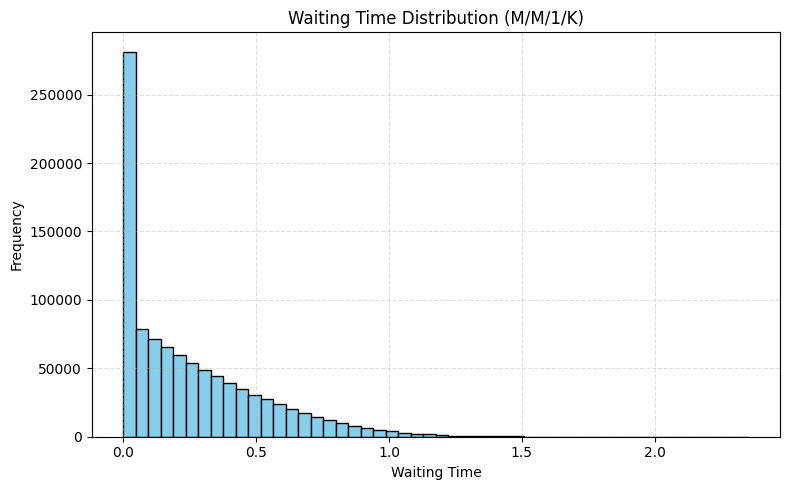

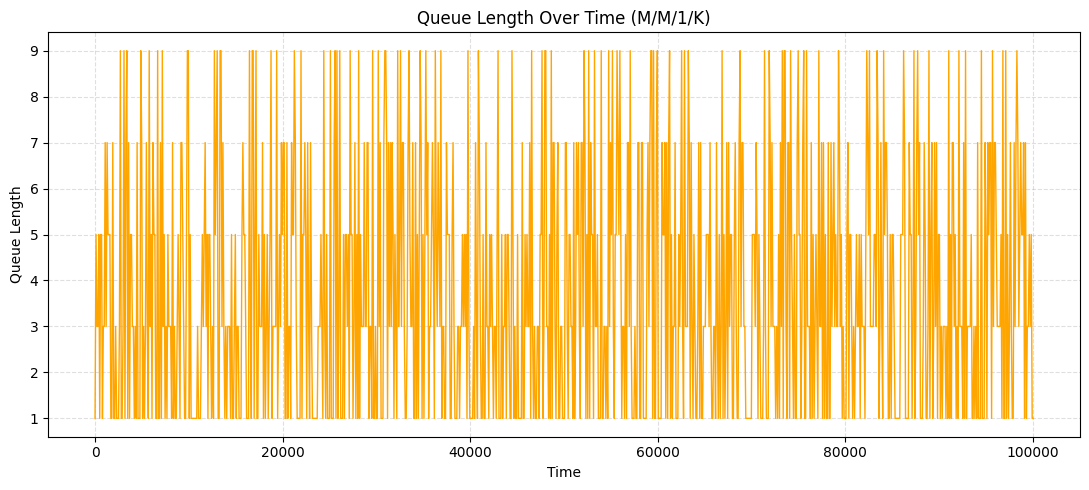


=== Simulation vs. Theory (M/M/1/K) ===
Parameters: lambda=10, mu=12, K=10, n=1000000
Utilization (rho): 0.8333

Blocking Probability:  sim=0.030551  |  theory=0.031104
Avg System Time (W):   sim=0.3380      |  theory=0.3395
Avg Waiting Time (Wq): sim=0.2548              |  theory=0.2562

Average Number in System (L):  sim=3.3663  |  theory=3.2893
Average Number in Queue (Lq):  sim=2.3969 |  theory=2.3204


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ----------- Helpers -----------
def exp_rv(rate, n):
    return np.random.exponential(1 / rate, n)

def generate_arrivals(lambda_, n):
    inter = exp_rv(lambda_, n)
    return np.cumsum(inter)

# ----------- Theory for M/M/1/K -----------
def theory_mm1k(lambda_, mu, K):
    rho = lambda_ / mu

    if abs(rho - 1.0) < 1e-12:
        P = [1.0 / (K + 1)] * (K + 1)
        P_block = P[K]
        L = sum(n * P[n] for n in range(K + 1))
        lambda_eff = lambda_ * (1 - P_block)
        W = L / lambda_eff if lambda_eff > 0 else 0.0
        Wq = W - 1 / mu
    else:
        denom = 1 - rho**(K + 1)
        P = [(1 - rho) * rho**n / denom for n in range(K + 1)]
        P_block = P[K]
        lambda_eff = lambda_ * (1 - P_block)
        L = sum(n * P[n] for n in range(K + 1))
        W = L / lambda_eff if lambda_eff > 0 else 0.0
        Wq = W - 1 / mu

    return {
        "rho": rho,
        "P_block": P_block,
        "lambda_eff": lambda_eff,
        "L": L,
        "W": W,
        "Wq": Wq,
    }

# ----------- M/M/1/K Simulation -----------
def simulate_mm1k(lambda_, mu, K, n, show_plots=True):
    arrivals = generate_arrivals(lambda_, n)
    services = exp_rv(mu, n)

    start = []
    finish = []
    accepted_arrivals = []
    queue = []
    blocked_count = 0

    events = []  # (time, +1 arrival, -1 departure)

    for i in range(n):
        queue = [f for f in queue if f > arrivals[i]]

        if len(queue) < K:
            s = max(arrivals[i], queue[-1] if queue else 0.0)
            f = s + services[i]
            start.append(s)
            finish.append(f)
            accepted_arrivals.append(arrivals[i])
            queue.append(f)

            events.append((arrivals[i], +1))
            events.append((f, -1))
        else:
            blocked_count += 1

    real_n = len(start)
    if real_n == 0:
        return {
            "avg_wait": 0.0,
            "avg_system_time": 0.0,
            "blocking_probability": blocked_count / n,
            "L": 0.0,
            "Lq": 0.0,
        }

    accepted_arrivals = np.array(accepted_arrivals)
    start = np.array(start)
    finish = np.array(finish)

    wait_times = start - accepted_arrivals
    system_times = finish - accepted_arrivals
    blocking_prob = blocked_count / n

    # Sort events
    events.sort()
    time_points, queue_length = [], []
    length = 0
    for t, delta in events:
        length += delta
        length = min(length, K)
        time_points.append(t)
        queue_length.append(length)

    # ---- NEW: compute L and Lq from the event-driven queue length curve ----
    time_points = np.array(time_points)
    queue_length = np.array(queue_length)

    durations = np.diff(time_points, prepend=time_points[0])
    total_time = time_points[-1] - time_points[0]

    L = np.sum(queue_length * durations) / total_time
    Lq = L - (1 - blocking_prob) * (1 / mu) * mu   # or simpler: Lq = L - (1 - blocking_prob)

    # --------- Plots ----------
    if show_plots:
        plt.figure(figsize=(8, 5))
        plt.hist(wait_times, bins=50, color='skyblue', edgecolor='k')
        plt.title("Waiting Time Distribution (M/M/1/K)")
        plt.xlabel("Waiting Time")
        plt.ylabel("Frequency")
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()
        print()

        max_points = 1000
        stride = max(1, len(time_points) // max_points)
        tp = time_points[::stride]
        ql = queue_length[::stride]

        plt.figure(figsize=(11, 5))
        plt.plot(tp, ql, color='orange', linewidth=1)
        plt.title("Queue Length Over Time (M/M/1/K)")
        plt.xlabel("Time")
        plt.ylabel("Queue Length")
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

    return {
        "avg_wait": float(np.mean(wait_times)),
        "avg_system_time": float(np.mean(system_times)),
        "blocking_probability": float(blocking_prob),
        "L": float(L),
        "Lq": float(Lq),
    }

# ----------- Compare -----------
def compare_simulation_vs_theory(lambda_, mu, K, n, show_plots=True):
    sim = simulate_mm1k(lambda_, mu, K, n=n, show_plots=show_plots)
    th = theory_mm1k(lambda_, mu, K)

    print("\n=== Simulation vs. Theory (M/M/1/K) ===")
    print(f"Parameters: lambda={lambda_}, mu={mu}, K={K}, n={n}")
    print(f"Utilization (rho): {th['rho']:.4f}")
    print(f"\nBlocking Probability:  sim={sim['blocking_probability']:.6f}  |  theory={th['P_block']:.6f}")
    print(f"Avg System Time (W):   sim={sim['avg_system_time']:.4f}      |  theory={th['W']:.4f}")
    print(f"Avg Waiting Time (Wq): sim={sim['avg_wait']:.4f}              |  theory={th['Wq']:.4f}")
    print(f"\nAverage Number in System (L):  sim={sim['L']:.4f}  |  theory={th['L']:.4f}")
    print(f"Average Number in Queue (Lq):  sim={sim['Lq']:.4f} |  theory={th['L'] - (1 - th['P_block']):.4f}")

    return sim, th

# ----------- Example Execution -----------
if __name__ == "__main__":
    lambda_ = 10
    mu = 12
    K = 10
    n = 10**6

    sim_results, theory_results = compare_simulation_vs_theory(lambda_, mu, K, n=n, show_plots=True)
